<a href="https://colab.research.google.com/github/annhater/M1_STAGE/blob/main/2_notebooks/01_metrics_RMSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Calculate RMSF


In [ ]:
!pip install MDAnalysis
!pip install MDAnalysisTests

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 857.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 882.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━ 28.1/57.9 MB 168.2 kB/s eta 0:02:58
ERROR: Operation cancelled by user


In [ ]:
#IMPORTS
import numpy as np
import MDAnalysis as mda
from MDAnalysis.analysis import rms, align
import matplotlib.pyplot as plt
from MDAnalysis.analysis.rms import RMSF
import os

# SETUP
# set working dir
rootdir = '/content/drive/MyDrive/M1_STAGE/Data/simulations_1HSI/'
os.chdir(rootdir)

# FUNCTIONS

# a. RMSF with MDAnalysis
def get_rmsf(gro, xtc):
    u = mda.Universe(gro, xtc)
    # 1. alignment of the trajectory
    average = align.AverageStructure(u, u, select='backbone').run()
    ref = average.universe
    aligner = align.AlignTraj(u, ref, select='backbone', in_memory=True).run()

    # 2. compute RMSF for C-alphas
    calphas = u.select_atoms("backbone")
    rmsfer = RMSF(calphas).run()
    return calphas.resids, rmsfer.results.rmsf

#MAIN

# 1. Fetch files from all simulations
cond1_files = [] # For simulations_1HSI_APO_MP
cond2_files = [] # For simulations_1HSI_APO_DP

for subdir, dirs, files in os.walk(rootdir):
    pdb_files_pathnames = [f for f in files if f.endswith("_renum.pdb")]
    xtc_files_pathnames = [f for f in files if f.endswith(".xtc")]

    for pdb_name in pdb_files_pathnames:
        sim_name_match = pdb_name.replace("_renum.pdb", "").replace("_all", "")

        found_xtc = None
        for xtc_name in xtc_files_pathnames:
            if sim_name_match in xtc_name  and xtc_name.endswith('.xtc'):
                found_xtc = xtc_name
                break
        if found_xtc:
            pdb_path = os.path.join(subdir, pdb_name)
            xtc_path = os.path.join(subdir, found_xtc)

            if "simulations_1HSI_APO_MP" in subdir:
                cond1_files.append((pdb_path, xtc_path))
            elif "simulations_1HSI_APO_DP" in subdir:
                cond2_files.append((pdb_path, xtc_path))

# 1.1. sort file pairs
cond1_files.sort()
cond2_files.sort()

# 2. Calculate RMSF

# 2.1. empty lists to store RMSF results
all_rmsf_c1 = []
all_resids_c1 = []
all_rmsf_c2 = []
all_resids_c2 = []

# 2.2. RMSF for c1
for gro, xtc in cond1_files:
    resids, rmsf = get_rmsf(gro, xtc)
    all_resids_c1.append(resids)
    all_rmsf_c1.append(rmsf)

# 2.3. RMSF for c2
for gro, xtc in cond2_files:
    resids, rmsf = get_rmsf(gro, xtc)
    all_resids_c2.append(resids)
    all_rmsf_c2.append(rmsf)



/usr/local/lib/python3.12/dist-packages/MDAnalysis/topology/PDBParser.py:376: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "
/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/XDR.py:261: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/MDAnalysis/analysis/align.py:1173: DeprecationWarning: The `universe` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.universe` instead.
  warnings.warn(wmsg, DeprecationWarning)


In [ ]:
#IMPORTS
import numpy as np
import pandas as pd
import MDAnalysis as mda
from MDAnalysis.analysis import rms, align
import matplotlib.pyplot as plt
from MDAnalysis.analysis.rms import RMSF
import os

# a. RMSF with MDAnalysis
def get_rmsf(gro, xtc):
    u = mda.Universe(gro, xtc)
    # 1. alignment of the trajectory
    average = align.AverageStructure(u, u, select='backbone').run()
    ref = average.universe
    aligner = align.AlignTraj(u, ref, select='backbone', in_memory=True).run()

    # 2. compute RMSF for C-alphas
    calphas = u.select_atoms("backbone")
    rmsfer = RMSF(calphas).run()
    return calphas.resids, rmsfer.results.rmsf

rmsf_array_v12 = get_rmsf('/content/drive/MyDrive/M1_STAGE/Data/simulations_1HSI/simulations_1HSI_APO_DP/V12/1HSI_AMBER_pH7_NPT.gro', '/content/drive/MyDrive/M1_STAGE/Data/simulations_1HSI/simulations_1HSI_APO_DP/V12/md_V12.xtc')
rmsf_array_v11 = get_rmsf('/content/drive/MyDrive/M1_STAGE/Data/simulations_1HSI/simulations_1HSI_APO_DP/V11/bipro_OD2_1HSI_AMBER.gro', '/content/drive/MyDrive/M1_STAGE/Data/simulations_1HSI/simulations_1HSI_APO_DP/V11/md_V11.xtc')
rmsf_array_v7 = get_rmsf('/content/drive/MyDrive/M1_STAGE/Data/simulations_1HSI/simulations_1HSI_APO_MP/V7/1HSI_pH7_24_oct_mini2.gro', '/content/drive/MyDrive/M1_STAGE/Data/simulations_1HSI/simulations_1HSI_APO_MP/V7/md_V7.xtc')
df = pd.DataFrame({'resids': rmsf_array_v12[0], 'rmsf_11': rmsf_array_v11[1],'rmsf_12': rmsf_array_v12[1],'rmsf_v7': rmsf_array_v7[1]})
df.query('47 < resids < 55')

/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/XDR.py:261: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/MDAnalysis/analysis/align.py:1173: DeprecationWarning: The `universe` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.universe` instead.
  warnings.warn(wmsg, DeprecationWarning)


,resids,rmsf_11,rmsf_12,rmsf_v7
188,48,3.468382,1.445023,1.512407
189,48,3.714612,1.548248,1.551347
190,48,3.977531,1.534167,1.609416
191,48,4.091917,1.795343,1.727801
192,49,4.358049,1.611095,1.795326
193,49,4.961844,1.902994,2.113602
194,49,5.324432,1.829077,2.291825
195,49,5.493036,1.870557,2.409795
196,50,5.717821,1.912165,2.493264
197,50,6.244682,1.980867,2.816128


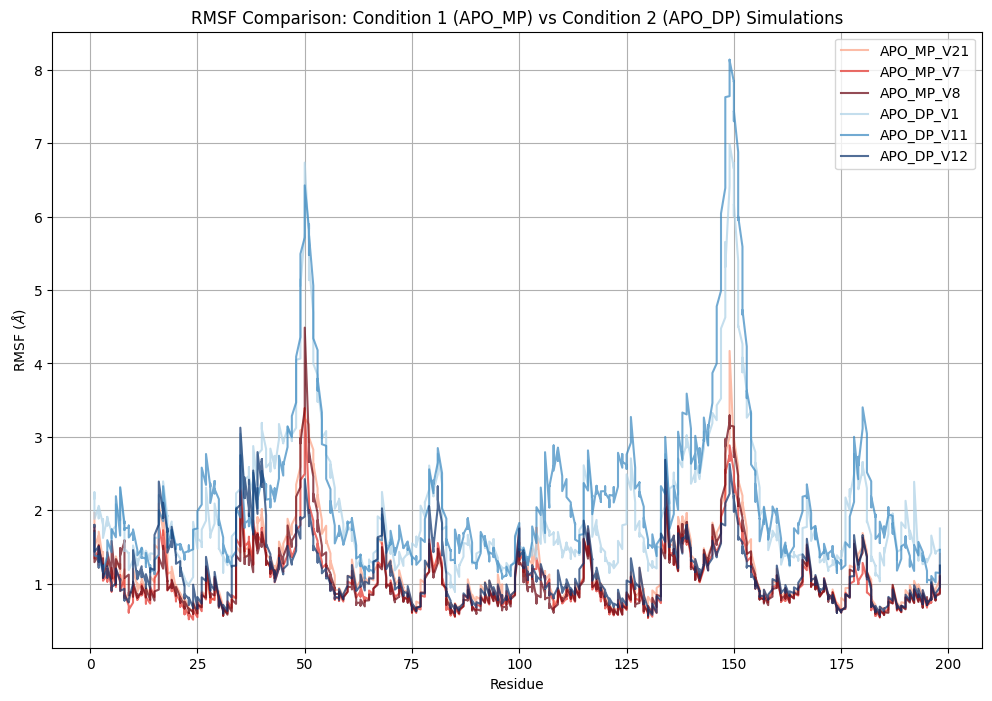

In [ ]:
# 3. Plot all RMSF
fig = plt.figure(figsize=(12, 8))

# 3.1. colors
n_c1 = len(all_rmsf_c1)
n_c2 = len(all_rmsf_c2)
cmap_c1 = plt.get_cmap('Reds', n_c1 + 1)
cmap_c2 = plt.get_cmap('Blues', n_c2 + 1)

# c1 RMSF plots
for i in range(len(all_rmsf_c1)):
    sim_dir_name = os.path.basename(os.path.dirname(cond1_files[i][0]))
    plt.plot(all_resids_c1[i], all_rmsf_c1[i], color=cmap_c1(i + 1), alpha=0.7, label=f"APO_MP_{sim_dir_name}")

# c2 RMSF plots
for i in range(len(all_rmsf_c2)):
    sim_dir_name = os.path.basename(os.path.dirname(cond2_files[i][0]))
    plt.plot(all_resids_c2[i], all_rmsf_c2[i], color=cmap_c2(i + 1), alpha=0.7, label=f"APO_DP_{sim_dir_name}")

plt.ylabel(r"RMSF ($\AA$)")
plt.xlabel("Residue")
plt.title("RMSF Comparison: Condition 1 (APO_MP) vs Condition 2 (APO_DP) Simulations")
plt.legend(loc='best')
plt.grid(True)
plt.show()
fig.savefig("/content/drive/MyDrive/M1_STAGE/Manips/Figures/rmsf_all_simulations.png")

In [ ]:
import pandas as pd # Make sure pandas is imported

#calculate the statistics
summary_stats_dict = {} # dico to store loop results

# Collect simulation names and corresponding RMSF data for individual simulations
all_sim_names = []
all_rmsf_data_combined = []
https://colab.research.google.com/drive/1kkH3i_ZIa572xK5R_VBgs27OnvGg6fcO?authuser=1#scrollTo=6XqCNX9HFt8
# For condition 1 individual simulations
for i, (pdb_path, xtc_path) in enumerate(cond1_files):
    # Extract sim_dir_name as used in the plotting cell
    sim_dir_name = os.path.basename(os.path.dirname(pdb_path))
    all_sim_names.append(f"APO_MP_{sim_dir_name}")
    all_rmsf_data_combined.append(all_rmsf_c1[i])

# For condition 2 individual simulations
for i, (pdb_path, xtc_path) in enumerate(cond2_files):
    sim_dir_name = os.path.basename(os.path.dirname(pdb_path))
    all_sim_names.append(f"APO_DP_{sim_dir_name}")
    all_rmsf_data_combined.append(all_rmsf_c2[i])

# Add individual simulation statistics to summary_stats_dict
for sim_name, rmsf_array in zip(all_sim_names, all_rmsf_data_combined):
    summary_stats_dict[sim_name] = pd.Series(rmsf_array).describe()

# Calculate descriptive statistics for all simulations in condition 1 combined
combined_rmsf_c1 = np.concatenate(all_rmsf_c1)
summary_stats_dict['Condition 1'] = pd.Series(combined_rmsf_c1).describe()

# Calculate descriptive statistics for all simulations in condition 2 combined
combined_rmsf_c2 = np.concatenate(all_rmsf_c2)
summary_stats_dict['Condition 2'] = pd.Series(combined_rmsf_c2).describe()

# Create the final DataFrame
summary_stats_df = pd.DataFrame(summary_stats_dict)


# write csv
summary_stats_df.to_csv('/content/drive/MyDrive/M1_STAGE/Manips/RMSF_stats.csv', index=True, header=True, decimal=".", float_format="%.3f")

In [ ]:
summary_stats_df

,APO_MP_V21,APO_MP_V7,APO_MP_V8,APO_DP_V1,APO_DP_V11,APO_DP_V12,APO_MP_Combined,APO_DP_Combined
count,790.000000,790.000000,790.000000,790.000000,790.000000,790.000000,2370.000000,2370.000000
mean,1.165467,1.030315,1.062482,1.992596,2.130950,1.138256,1.086088,1.753934
std,0.515995,0.416480,0.501058,0.966080,1.140444,0.427888,0.483099,0.998895
min,0.586493,0.506595,0.549795,0.888862,1.011542,0.572814,0.506595,0.572814
25%,0.819876,0.754613,0.755089,1.387411,1.459075,0.832266,0.773644,1.193263
50%,1.003251,0.890052,0.888325,1.671949,1.783400,1.016607,0.925655,1.505464
75%,1.370537,1.212664,1.258060,2.308007,2.359565,1.328353,1.276885,2.039006
max,4.170850,3.391141,4.488501,6.990208,8.140159,3.124294,4.488501,8.140159
